Files already downloaded and verified
Files already downloaded and verified
FLOPs: 127.622M
Params: 853.018K


/home/mtech/2025/poulami.mukherjee25m/.local/lib/python3.6/site-packages/sklearn/metrics/_classification.py:1248: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Epoch 1: Train 13.86% | Test 23.51%
Epoch 2: Train 25.40% | Test 30.04%
Epoch 3: Train 35.24% | Test 40.62%
Epoch 4: Train 43.35% | Test 45.49%
Epoch 5: Train 50.56% | Test 52.57%
Epoch 6: Train 56.85% | Test 53.80%
Epoch 7: Train 62.36% | Test 53.85%
Epoch 8: Train 66.91% | Test 61.04%
Epoch 9: Train 71.59% | Test 63.50%
Epoch 10: Train 74.33% | Test 61.84%
Epoch 11: Train 76.57% | Test 72.50%
Epoch 12: Train 78.49% | Test 71.40%
Epoch 13: Train 79.83% | Test 76.09%
Epoch 14: Train 80.66% | Test 73.55%
Epoch 15: Train 81.99% | Test 78.67%
Epoch 16: Train 83.05% | Test 77.31%
Epoch 17: Train 83.80% | Test 76.44%
Epoch 18: Train 84.39% | Test 69.99%
Epoch 19: Train 84.74% | Test 81.15%
Epoch 20: Train 85.37% | Test 82.08%
Epoch 21: Train 85.97% | Test 81.09%
Epoch 22: Train 86.18% | Test 79.71%
Epoch 23: Train 86.90% | Test 71.77%
Epoch 24: Train 87.03% | Test 81.02%
Epoch 25: Train 87.44% | Test 82.38%
Epoch 26: Train 87.69% | Test 79.92%
Epoch 27: Train 88.03% | Test 82.97%
Epoch 28: 

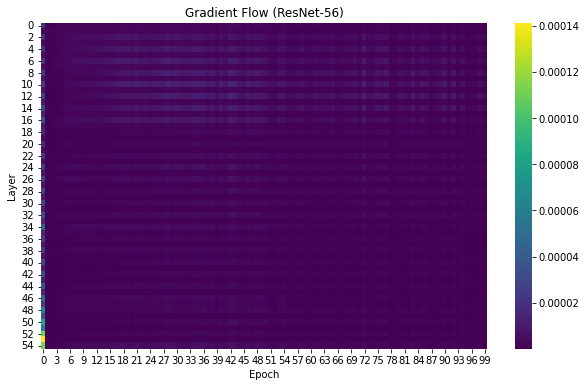

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn.metrics import precision_score, recall_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# Data (C10+ augmentation)
# -----------------------------
mean = (0.4914, 0.4822, 0.4465)
std = (0.2023, 0.1994, 0.2010)

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

trainset = torchvision.datasets.CIFAR10('./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10('./data', train=False, download=True, transform=transform_test)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)

# -----------------------------
# ResNet Block (Option A)
# -----------------------------
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()

        # Option A shortcut (paper)
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.AvgPool2d(2, stride=2),
                nn.ConstantPad3d((0, 0, 0, 0, out_channels//4, out_channels//4), 0)
            )

    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return torch.relu(out)

# -----------------------------
# ResNet-56 (n=9)
# -----------------------------
class ResNet(nn.Module):
    def __init__(self, n=9):
        super().__init__()

        self.in_channels = 16

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)

        self.layer1 = self._make_layer(16, n, stride=1)
        self.layer2 = self._make_layer(32, n, stride=2)
        self.layer3 = self._make_layer(64, n, stride=2)

        self.fc = nn.Linear(64, 10)

    def _make_layer(self, out_channels, blocks, stride):
        layers = []
        layers.append(BasicBlock(self.in_channels, out_channels, stride))
        self.in_channels = out_channels

        for _ in range(1, blocks):
            layers.append(BasicBlock(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = torch.nn.functional.avg_pool2d(out, 8)
        out = out.view(out.size(0), -1)
        return self.fc(out)

model = ResNet().to(device)

# -----------------------------
# FLOPs + Params
# -----------------------------
from thop import profile, clever_format

dummy = torch.randn(1, 3, 32, 32).to(device)
flops, params = profile(model, inputs=(dummy,), verbose=False)
flops, params = clever_format([flops, params], "%.3f")

print("FLOPs:", flops)
print("Params:", params)  # ~0.85M expected

# -----------------------------
# Gradient Hooks
# -----------------------------
gradients = {}
grad_history = []

def hook_fn(name):
    def hook(module, grad_input, grad_output):
        gradients[name] = grad_output[0].abs().mean().item()
    return hook

for name, layer in model.named_modules():
    if isinstance(layer, nn.Conv2d):
        layer.register_full_backward_hook(hook_fn(name))

# -----------------------------
# Training Setup
# -----------------------------
criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[50, 75],
    gamma=0.1
)

num_epochs = 100

history = {
    "Epoch": [],
    "Train Accuracy": [],
    "Test Accuracy Top1": [],
    "Test Accuracy Top5": [],
    "Train Loss": [],
    "Test Loss": [],
    "Precision": [],
    "Recall": []
}

train_acc_hist, test_acc_hist = [], []
train_loss_hist, test_loss_hist = [], []

# -----------------------------
# Evaluation
# -----------------------------
def evaluate(loader):
    model.eval()

    total_loss, correct1, correct5, total = 0, 0, 0, 0
    all_preds, all_targets = [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            total_loss += loss.item()

            _, p1 = out.max(1)
            correct1 += p1.eq(y).sum().item()

            _, p5 = out.topk(5, dim=1)
            correct5 += sum(y[i] in p5[i] for i in range(y.size(0)))

            total += y.size(0)

            all_preds.extend(p1.cpu().numpy())
            all_targets.extend(y.cpu().numpy())

    acc1 = 100 * correct1 / total
    acc5 = 100 * correct5 / total
    loss = total_loss / len(loader)

    precision = precision_score(all_targets, all_preds, average='macro')
    recall = recall_score(all_targets, all_preds, average='macro')

    return loss, acc1, acc5, precision, recall

# -----------------------------
# Training Loop
# -----------------------------
for epoch in range(num_epochs):
    model.train()

    running_loss, correct, total = 0, 0, 0

    for i, (x, y) in enumerate(trainloader):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()

        if i == 0:
            grad_history.append(list(gradients.values()))

        optimizer.step()

        running_loss += loss.item()
        _, pred = out.max(1)
        total += y.size(0)
        correct += pred.eq(y).sum().item()

    train_loss = running_loss / len(trainloader)
    train_acc = 100 * correct / total

    test_loss, test_acc1, test_acc5, precision, recall = evaluate(testloader)

    scheduler.step()

    train_loss_hist.append(train_loss)
    test_loss_hist.append(test_loss)
    train_acc_hist.append(train_acc)
    test_acc_hist.append(test_acc1)

    history["Epoch"].append(epoch+1)
    history["Train Accuracy"].append(train_acc)
    history["Test Accuracy Top1"].append(test_acc1)
    history["Test Accuracy Top5"].append(test_acc5)
    history["Train Loss"].append(train_loss)
    history["Test Loss"].append(test_loss)
    history["Precision"].append(precision)
    history["Recall"].append(recall)

    print(f"Epoch {epoch+1}: Train {train_acc:.2f}% | Test {test_acc1:.2f}%")

# -----------------------------
# Final Test Evaluation
# -----------------------------
model.eval()

total, correct1, correct5, total_loss = 0, 0, 0, 0
all_preds, all_targets = [], []

with torch.no_grad():
    for x, y in testloader:
        x, y = x.to(device), y.to(device)

        out = model(x)
        loss = criterion(out, y)

        total_loss += loss.item()

        _, p1 = out.max(1)
        correct1 += p1.eq(y).sum().item()

        _, p5 = out.topk(5, dim=1)
        correct5 += sum(y[i] in p5[i] for i in range(y.size(0)))

        total += y.size(0)

        all_preds.extend(p1.cpu().numpy())
        all_targets.extend(y.cpu().numpy())

final_acc1 = 100 * correct1 / total
final_acc5 = 100 * correct5 / total
final_loss = total_loss / len(testloader)

precision = precision_score(all_targets, all_preds, average='macro')
recall = recall_score(all_targets, all_preds, average='macro')

print("\nFINAL RESULTS (ResNet-56)")
print("Top-1:", final_acc1)
print("Top-5:", final_acc5)
print("Loss:", final_loss)
print("Precision:", precision)
print("Recall:", recall)

# -----------------------------
# Save
# -----------------------------
torch.save(model.state_dict(), "resnet56.pth")
pd.DataFrame(history).to_excel("resnet56_results.xlsx", index=False)

# -----------------------------
# Heatmap
# -----------------------------
grad_matrix = np.array(grad_history).T

plt.figure(figsize=(10,6))
sns.heatmap(grad_matrix, cmap="viridis")
plt.title("Gradient Flow (ResNet-56)")
plt.xlabel("Epoch")
plt.ylabel("Layer")
plt.show()

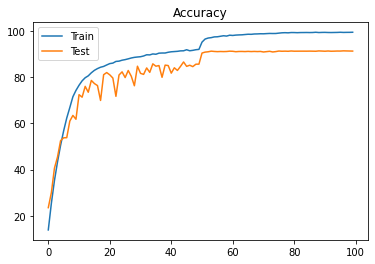

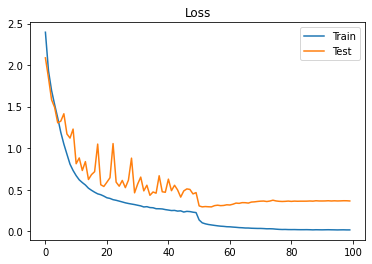

In [3]:
# -----------------------------
# Plots
# -----------------------------
plt.plot(train_acc_hist, label="Train")
plt.plot(test_acc_hist, label="Test")
plt.title("Accuracy")
plt.legend()
plt.show()

plt.plot(train_loss_hist, label="Train")
plt.plot(test_loss_hist, label="Test")
plt.title("Loss")
plt.legend()
plt.show()